# Introduction

This is a quick exploration of the available data for this competition.

It is not intended to be an exhaustive data exploration notebook, just one starter one.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# Prepare the data

In [2]:
train_df = pd.read_csv("/kaggle/input/deep-past-initiative-machine-translation/train.csv")
test_df = pd.read_csv("/kaggle/input/deep-past-initiative-machine-translation/test.csv")

publications_df = pd.read_csv("/kaggle/input/deep-past-initiative-machine-translation/publications.csv")
published_texts_df = pd.read_csv("/kaggle/input/deep-past-initiative-machine-translation/published_texts.csv")
bibliography_df = pd.read_csv("/kaggle/input/deep-past-initiative-machine-translation/bibliography.csv")
qa_lexicon_df = pd.read_csv("/kaggle/input/deep-past-initiative-machine-translation/OA_Lexicon_eBL.csv")



## Quick glimpse of the data

In [3]:
train_df.shape, test_df.shape, publications_df.shape, published_texts_df.shape, bibliography_df.shape, qa_lexicon_df.shape

((1561, 3), (4, 5), (216602, 4), (7953, 19), (878, 8), (39332, 9))

In [4]:
train_df.head(2)

,oare_id,transliteration,translation
0,004a7dbd-57ce-46f8-9691-409be61c676e,KIŠIB ma-nu-ba-lúm-a-šur DUMU ṣí-lá-(d)IM KIŠI...,"Seal of Mannum-balum-Aššur son of Ṣilli-Adad, ..."
1,0064939c-59b9-4448-a63d-34612af0a1b5,1 TÚG ša qá-tim i-tur₄-DINGIR il₅-qé,Itūr-ilī has received one textile of ordinary ...


In [5]:
test_df.head(2)

,id,text_id,line_start,line_end,transliteration
0,0,332fda50,1,7,um-ma kà-ru-um kà-ni-ia-ma a-na aa-qí-il… da-t...
1,1,332fda50,7,14,i-na mup-pì-im aa a-lim(ki) ia-tù u„-mì-im a-n...


In [6]:
publications_df.head(2)

,pdf_name,page,page_text,has_akkadian
0,"(OCR) AfO 51, 2005-06, pp. 247-249 - Kryszat, ...",1,Kleine Mitteilungen\nAltassyrische Miszellen 2...,False
1,"(OCR) AfO 51, 2005-06, pp. 247-249 - Kryszat, ...",2,248\nKleine Mitteilungen\nKleine Mitteilungen\...,False


In [7]:
published_texts_df.head(2)

,oare_id,online transcript,cdli_id,aliases,label,publication_catalog,description,genre_label,inventory_position,online_catalog,note,interlinear_commentary,online_information,excavation_no,oatp_key,eBL_id,AICC_translation,transliteration_orig,transliteration
0,bd4b7138-70d5-490d-8234-299b0a75d3a3,https://oare.byu.edu/epigraphies/bd4b7138-70d5...,P361099,MP 1 bis,Cuneiform Tablet RA 60 125,RA 60 125,"Cuneiform envelope, dated to the Old Assyrian ...",letter,MP 1 bis,NaN,Collection: MP 1 bis,"P. Garelli RA 60 S. 124-125; Michel Innaya II,...",NaN,NaN,4395,NaN,https://aicuneiform.com/search?q=P361099,KIŠIB a-šùr-ma-lik DUMU i-na-a a-na a-šùr-na-d...,KIŠIB a-šùr-ma-lik DUMU i-na-a a-na a-šùr-na-d...
1,b05376c2-fc3d-49f8-9792-a25c0df9c383,https://oare.byu.edu/epigraphies/b05376c2-fc3d...,P359543,ICK 1 146,Cuneiform Tablet ICK 1 146,Ka 185 | Ka 455 | Ka 424?,"Cuneiform tablet, dated to the Old Assyrian Pe...",debt note,Ist Ka 185 | Ist Ka 455 | Ist Ka 424?,NaN,"ICK 1, 146 & ICK 2, 33 (env) + ICK 2, 163 (env)","Ichisar, Imdilum 65f.",NaN,NaN,1888,NaN,https://aicuneiform.com/search?q=P359543,0.33333 ma-na 7 GÍN KÙ.BABBAR ṣa-ru-pá-am i-ṣé...,0.33333 ma-na 7 GÍN KÙ.BABBAR ṣa-ru-pá-am i-ṣé...


In [8]:
bibliography_df.head(2)

,pdf_name,title,author,author_place,journal,volume,year,pages
0,"(OCR) AfO 51, 2005-06, pp. 247-249 - Kryszat, ...",Kleine Mitteilungen,Guido Kryszat,Mainz,Archiv für Orientforschung,51,2005/2006,247–249
1,"(OCR) CDOG 8, 2008, pp. 109-124 - Dercksen, J....",The Assyrian Colony at Kanesh,Jan Gerrit Dercksen,Leiden,NaN,NaN,2008,NaN


In [9]:
qa_lexicon_df.head(2)

,type,form,norm,lexeme,eBL,I_IV,A_D,Female(f),Alt_lex
0,word,áb ša-ra-ni,ab šarrānē,ab šarrānē,https://www.ebl.lmu.de/dictionary?word=ab šarrānē,NaN,NaN,NaN,NaN
1,word,áb ša-ra-nim,ab šarrānem,ab šarrānē,https://www.ebl.lmu.de/dictionary?word=ab šarrānē,NaN,NaN,NaN,NaN


# Data analysis

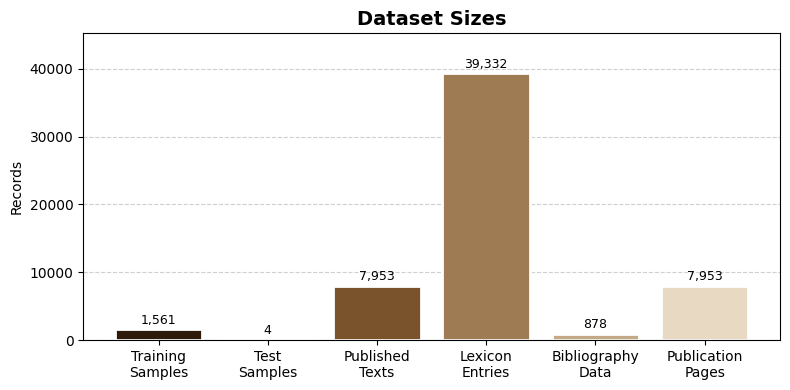

In [10]:
# Visual overview of dataset sizes
fig, ax = plt.subplots(figsize=(8,4))

sizes = [len(train_df), len(test_df), len(published_texts_df), len(qa_lexicon_df), len(bibliography_df), len(published_texts_df)]
names = ['Training\nSamples', 'Test\nSamples', 'Published\nTexts', 'Lexicon\nEntries', 'Bibliography\nData', 'Publication\nPages']
colors = ['#2e1a0b', '#553312', '#7a522c', '#9e7b52', '#c3a985', '#e8d9c3']

bars = ax.bar(names, sizes, color=colors, edgecolor='white', linewidth=2)

# Add gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)  # Ensures gridlines are behind bars

# Add value labels
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(sizes)*0.01, 
            f'{size:,}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Records', fontsize=10)
ax.set_title('Dataset Sizes', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(sizes) * 1.15)


plt.tight_layout()
plt.show()


Let's look to some examples of text.

In [11]:
for i in [0, 10, 100, 1000]:
    print(f"\n{'─'*70}")
    print(f"Document {i} (oare_id: {train_df.iloc[i]['oare_id'][:20]}...)")
    print(f"{'─'*70}")
    print(f"\nTransliteration:")
    print(f"{train_df.iloc[i]['transliteration'][:300]}...")
    print(f"\nEnglish translation:")
    print(f"{train_df.iloc[i]['translation'][:300]}...")


──────────────────────────────────────────────────────────────────────
Document 0 (oare_id: 004a7dbd-57ce-46f8-9...)
──────────────────────────────────────────────────────────────────────

Transliteration:
KIŠIB ma-nu-ba-lúm-a-šur DUMU ṣí-lá-(d)IM KIŠIB šu-(d)EN.LÍL DUMU ma-nu-ki-a-šur KIŠIB MAN-a-šur DUMU a-ta-a 0.33333 ma-na 2 GÍN KÙ.BABBAR SIG₅ i-ṣé-er PUZUR₄-a-šur DUMU a-ta-a a-lá-ḫu-um i-šu iš-tù ḫa-muš-tim ša ì-lí-dan ITU.KAM ša ke-na-tim li-mu-um e-na-sú-in a-na ITU 14 ḫa-am-ša-tim i-ša-qal šu-...

English translation:
Seal of Mannum-balum-Aššur son of Ṣilli-Adad, seal of Šu-Illil son of Mannum-kī-Aššur, seal of Puzur-Aššur son of Ataya. Puzur-Aššur son of Ataya owes 22 shekels of good silver to Ali-ahum. Reckoned from the week of Ilī-dan, month of Ša-kēnātim, in the eponymy of Enna-Suen, he will pay in 14 weeks. ...

──────────────────────────────────────────────────────────────────────
Document 10 (oare_id: 01cdba65-cee2-4988-b...)
────────────────────────────────────────────

In [12]:
# Analyze transliteration patterns
all_translit = ' '.join(train_df['transliteration'].tolist())

print("Transliteration Format Analysis")
print("="*70)

# 1. Hyphenation
print(f"\n{'─'*70}")
words = all_translit.split()
hyphenated = [w for w in words if '-' in w]
print(f"\nHyphenation:")
print(f"   Total tokens: {len(words):,}")
print(f"   Hyphenated tokens: {len(hyphenated):,} ({100*len(hyphenated)/len(words):.1f}%)")
print(f"   Sample: {hyphenated[:5]}")

# 2. ALL CAPS (Sumerian logograms)
print(f"\n{'─'*70}")
caps_pattern = re.compile(r'\b[A-ZŠṢṬḪ][A-ZŠṢṬḪ₀-₉\.]+\b')
caps_words = caps_pattern.findall(all_translit)
caps_counts = Counter(caps_words)
print(f"\nSumerian Logograms (All Caps):")
print(f"   Total occurrences: {len(caps_words):,}")
print(f"   Unique logograms: {len(caps_counts):,}")
print(f"   Top 10: {caps_counts.most_common(10)}")

# 3. Determinatives - check if present
print(f"\n{'─'*70}")
determinatives = re.findall(r'\{[^}]+\}', all_translit)
parens_det = re.findall(r'\([^)]+\)', all_translit)
print(f"\nDeterminatives:")
print(f"   Curly brackets {{...}}: {len(determinatives)}")
print(f"   Parentheses (...): {len(parens_det)}")
if parens_det:
    print(f"   Sample parentheses: {list(set(parens_det))[:10]}")

# 4. Subscript numbers
print(f"\n{'─'*70}")
subscripts = re.findall(r'[a-zšṣṭḫ]+[₀-₉]+', all_translit)
subscript_counts = Counter(subscripts)
print(f"\nSubscript Numbers:")
print(f"   Total occurrences: {len(subscripts):,}")
print(f"   Unique forms: {len(subscript_counts):,}")
print(f"   Top 10: {subscript_counts.most_common(10)}")

# 5. Fractions/decimals (representing ancient measures)
print(f"\n{'─'*70}")
fractions = re.findall(r'\d+\.\d+', all_translit)
print(f"\nFractions / Decimals:")
print(f"   Total occurrences: {len(fractions):,}")
print(f"   Sample values: {list(set(fractions))[:10]}")

# 6. Special punctuation
print(f"\n{'─'*70}")
print(f"\nSpecial Punctuation:")
print(f"   Square brackets []: {all_translit.count('[') + all_translit.count(']')}")
print(f"   Parentheses (): {all_translit.count('(') + all_translit.count(')')}")
print(f"   Half brackets ˹˺: {all_translit.count('˹') + all_translit.count('˺')}")
print(f"   Question marks: {all_translit.count('?')}")
print(f"   Exclamation marks: {all_translit.count('!')}")


Transliteration Format Analysis

──────────────────────────────────────────────────────────────────────

Hyphenation:
   Total tokens: 89,807
   Hyphenated tokens: 56,123 (62.5%)
   Sample: ['ma-nu-ba-lúm-a-šur', 'ṣí-lá-(d)IM', 'šu-(d)EN.LÍL', 'ma-nu-ki-a-šur', 'MAN-a-šur']

──────────────────────────────────────────────────────────────────────

Sumerian Logograms (All Caps):
   Total occurrences: 13,392
   Unique logograms: 167
   Top 10: [('BABBAR', 3390), ('DUMU', 1901), ('IGI', 1128), ('IŠTAR', 713), ('URUDU', 578), ('KIŠIB', 520), ('AN.NA', 490), ('DINGIR', 344), ('SIG₅', 325), ('ḪI.A', 250)]

──────────────────────────────────────────────────────────────────────

Determinatives:
   Curly brackets {...}: 0
   Parentheses (...): 1098
   Sample parentheses: ['(5 broken lines)', '(d-x x áš-pu-ru-ma x x ma-na 4 GÍN KÙ.BABBAR … x x ki lu šu x x GÍN KÙ.BABBAR ga … x ma-na KÙ.BABBAR x ša-da-aḫ-šu … … ib ri … 1 ma-na 5 GÍN KÙ.BABBAR iš-tí … 0.33333 ma-na KÙ.BABBAR iš-tí … x ma-na KÙ.BABBA

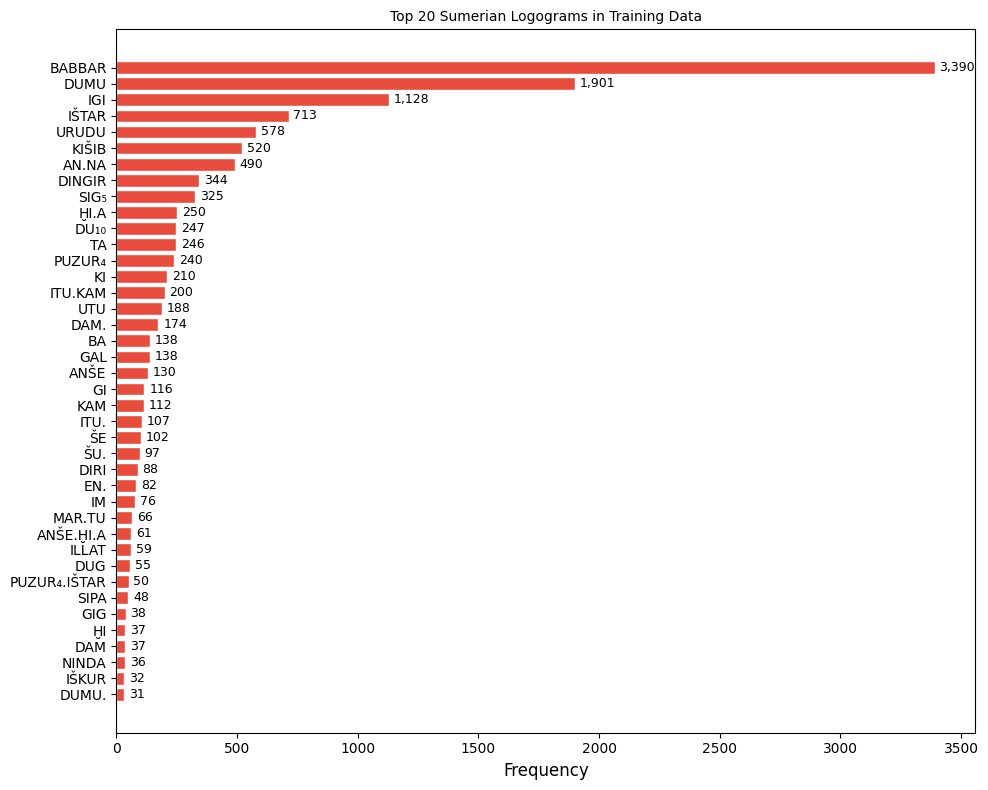

In [13]:
# Visualize Sumerian logogram distribution
top_logograms = caps_counts.most_common(40)

fig, ax = plt.subplots(figsize=(10,8))
names = [x[0] for x in top_logograms]
counts = [x[1] for x in top_logograms]

bars = ax.barh(names[::-1], counts[::-1], color='#e74c3c', edgecolor='white')
ax.set_xlabel('Frequency', fontsize=12)
ax.set_title("Top 20 Sumerian Logograms in Training Data", fontsize=10)

# Add value labels
for bar, count in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

We can observe that some of the most frequent logograms have similar form. For example:
* "DAM" and "DAM."
* "DUMU." and "DUMU"

# Prepare a baseline model

## Additional imports

In [14]:
import re, unicodedata

from collections import Counter, defaultdict
from difflib import SequenceMatcher
from sklearn.feature_extraction.text import TfidfVectorizer

## Configurations

In [15]:
# ===================== PARAMS =====================
USE_PUBLISHED = False
BATCH = 256

TOPK = 80
RERANK_K = 20

W_CHAR = 0.82
W_WORD = 0.18
W_SEQ  = 0.08

MIN_NNZ = 4

# ===================== NORMALIZATION =====================
SUB_MAP = str.maketrans({"₀":"0","₁":"1","₂":"2","₃":"3","₄":"4","₅":"5","₆":"6","₇":"7","₈":"8","₉":"9"})

SPECIAL = {
    "š":"sh","Š":"sh","ṣ":"s2","Ṣ":"s2","ṭ":"t2","Ṭ":"t2",
    "ḫ":"h2","Ḫ":"h2","ā":"aa","Ā":"aa","ē":"ee","Ē":"ee",
    "ī":"ii","Ī":"ii","ū":"uu","Ū":"uu",
}

## Utilities

In [16]:
def clean_ws(x):
    if pd.isna(x): return ""
    return re.sub(r"\s+", " ", str(x)).strip()

def strip_combining(s):
    s = unicodedata.normalize("NFKD", s)
    return "".join(c for c in s if not unicodedata.combining(c))

def norm_src(x):
    if pd.isna(x): return ""
    x = clean_ws(x).lower().translate(SUB_MAP)
    x = re.sub(r"\{([^}]+)\}", r" DET_\1 ", x)
    x = re.sub(r"\(([a-z]{1,6})\)", r" DET_\1 ", x)
    for k,v in SPECIAL.items(): x = x.replace(k,v)
    x = strip_combining(x)
    x = re.sub(r"[ʾʿˀˁ']", "", x)
    x = x.replace("…"," GAP ").replace("..."," GAP ")
    x = re.sub(r"\b[xX]{1,3}\b"," GAP ",x)
    x = x.replace("["," ").replace("]"," ").replace("<"," ").replace(">"," ")
    x = x.replace("."," ").replace("+","")
    x = re.sub(r"[^a-z0-9\-_ ]+"," ",x)
    return re.sub(r"\s+"," ",x).strip()

def norm_tgt(x):
    if pd.isna(x): return ""
    x = clean_ws(x)
    x = x.replace("“",'"').replace("”",'"').replace("’","'")
    return x

META_PREFIX = re.compile(r"^\s*(Seal of|Sealed by|Envelope|Copy of|Impression of)\b", re.I)

def strip_leading_metadata(en):
    en = norm_tgt(en)
    parts = re.split(r"(?<=[.!?])\s+", en)
    if len(parts)>=2 and META_PREFIX.search(parts[0]):
        return " ".join(parts[1:])
    return en

def make_one_sentence(en):
    parts = re.split(r"(?<=[.!?])\s+", norm_tgt(en))
    parts = [re.sub(r"[.!?]+$","",p.strip()) for p in parts if p.strip()]
    out = "; ".join(parts) if parts else "..."
    return out + "."

def finalize_translation(en):
    return make_one_sentence(strip_leading_metadata(en))

def bleu_safe(en):
    en = en.strip()
    en = re.sub(r"\s+([.,;:])", r"\1", en)
    en = re.sub(r"([.,;:])(?=\S)", r"\1 ", en)
    en = re.sub(r"\s+", " ", en)
    return en if en.endswith(".") else en+"."


## Data preparation

In [17]:
mem = train_df[["transliteration","translation"]].copy()
if USE_PUBLISHED:
    mem = pd.concat([mem, published[["transliteration","translation"]]])

mem["src_norm"] = mem["transliteration"].map(norm_src)
mem["tgt"] = mem["translation"].map(norm_tgt)
mem = mem[(mem.src_norm!="") & (mem.tgt!="")]

mem = mem.groupby("src_norm",as_index=False).agg({"tgt":lambda x:x.value_counts().idxmax()})

mem_src = mem.src_norm.tolist()
mem_tgt = mem.tgt.tolist()
exact_map = dict(zip(mem_src,mem_tgt))
mem_src_len = np.array([max(1,len(s.split())) for s in mem_src])

print("TM rows:", len(mem))

TM rows: 1559


## Vectorization

In [18]:
char_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,7))
word_vec = TfidfVectorizer(analyzer="word", ngram_range=(1,2),
                           token_pattern=r"(?u)\b[a-z0-9\-_]+\b")

Xc = char_vec.fit_transform(mem_src)
Xw = word_vec.fit_transform(mem_src)

## Backoff dictionary

In [19]:
src_norm = train_df.transliteration.map(norm_src)
tgt_norm = train_df.translation.map(norm_tgt)

src_cnt, tgt_cnt, pair_cnt = Counter(), Counter(), Counter()
surface = defaultdict(Counter)

for s,t in zip(src_norm,tgt_norm):
    st = set(s.split())
    tt = set(w.lower() for w in t.split())
    for w in t.split(): surface[w.lower()][w]+=1
    for a in st: src_cnt[a]+=1
    for b in tt: tgt_cnt[b]+=1
    for a in st:
        for b in tt: pair_cnt[(a,b)]+=1

best_word,best_score={},{}
for (a,b),c in pair_cnt.items():
    sc = c/np.sqrt(src_cnt[a]*tgt_cnt[b])
    if sc>best_score.get(a,0):
        best_score[a]=sc; best_word[a]=b

best_surface={k:v.most_common(1)[0][0] for k,v in surface.items()}

def dict_backoff(q):
    out=[]
    for w in q.split():
        if w.startswith("det_") or w=="gap": continue
        if w in best_word and best_score[w]>=0.10:
            out.append(best_surface.get(best_word[w],best_word[w]))
        else: out.append(w)
    return finalize_translation(" ".join(out))

## Scoring

In [20]:
def length_penalty(q_len,cand_len):
    power = 1.3 if q_len<=8 else 1.8
    r = cand_len/q_len
    return np.exp(-np.abs(np.log(r))*power)

def min_accept(q_len):
    return 0.14 if q_len<=7 else 0.18

## Inference

In [21]:
test_q = test_df.transliteration.map(norm_src).tolist()
preds=[""]*len(test_q)

need=[]
for i,q in enumerate(test_q):
    if q in exact_map:
        preds[i]=bleu_safe(finalize_translation(exact_map[q]))
    else: need.append(i)

for st in range(0,len(need),BATCH):
    idx=need[st:st+BATCH]
    qs=[test_q[i] for i in idx]

    qc=char_vec.transform(qs)
    qw=word_vec.transform(qs)
    nnz=qc.getnnz(1)+qw.getnnz(1)

    sc=(qc@Xc.T).toarray()
    sw=(qw@Xw.T).toarray()
    base=W_CHAR*sc+W_WORD*sw

    for r,i in enumerate(idx):
        q=qs[r]
        if nnz[r]<MIN_NNZ:
            preds[i]=bleu_safe(dict_backoff(q)); continue

        row=base[r]
        cand=np.argpartition(-row,TOPK)[:TOPK]
        lp=length_penalty(len(q.split()),mem_src_len[cand])
        score=row[cand]*lp

        top=cand[np.argpartition(-score,RERANK_K)[:RERANK_K]]

        best_s,best_i=-1,None
        for c in top:
            s=row[c]*length_penalty(len(q.split()),np.array([mem_src_len[c]]))[0]
            s+=W_SEQ*SequenceMatcher(None,q,mem_src[c]).ratio()
            if s>best_s: best_s,best_i=s,c

        if best_i is None or best_s<min_accept(len(q.split())):
            preds[i]=bleu_safe(dict_backoff(q))
        else:
            preds[i]=bleu_safe(mem_tgt[best_i])


## Submission

In [22]:
sub=pd.DataFrame({"id":test_df.id,"translation":preds})
sub.to_csv("submission.csv",index=False)

Note: this is a very preliminary submission.